<a href="https://colab.research.google.com/github/graciousgift/OIBSIP/blob/main/Gift_Lawrence_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/Unemployment in India.csv")
df.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df_1=pd.read_csv("/content/Unemployment_Rate_upto_11_2020.csv")
df_1.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


# 1. Understanding the Data Sets

In [ ]:
df.info()
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                  

In [ ]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
df_1.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [ ]:
df.shape , df_1.shape



((768, 7), (267, 9))

In [ ]:
df.isna().sum()



,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
df_1.isna().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


# 2. Clean Data Set

In [ ]:
#Remove hidden spaces from column names
df.columns = df.columns.str.strip()

df_1.columns = df_1.columns.str.strip()


In [ ]:
 #Drop rows where all values are missing
df.dropna(inplace=True)
df_1.dropna(inplace=True)


In [ ]:
# Convert Date column from text → real date objects
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)
df_1['Date'] = pd.to_datetime(df_1['Date'].str.strip(), dayfirst=True)

# Short nicknames for long column names
UNEMP = 'Estimated Unemployment Rate (%)'
EMPL  = 'Estimated Employed'
LPR   = 'Estimated Labour Participation Rate (%)'

#Tag rows as Pre-Covid vs During Covid
LOCKDOWN = pd.Timestamp('2020-03-25')   # India lockdown date
df_1['Period'] = df_1['Date'].apply(
    lambda d: 'During Covid' if d >= LOCKDOWN else 'Pre-Covid'
)


In [ ]:
# Summary statistics for both datasets
print("── df stats ──")
print(df[[UNEMP, EMPL, LPR]].describe().round(2))

print("── df_1 stats ──")
print(df_1[[UNEMP, EMPL, LPR]].describe().round(2))

# Compare Pre-Covid vs During Covid averages
pre_avg   = df_1[df_1['Period'] == 'Pre-Covid'   ][UNEMP].mean()
covid_avg = df_1[df_1['Period'] == 'During Covid'][UNEMP].mean()

print(f"Pre-Covid average   : {pre_avg:.2f}%")
print(f"During Covid average: {covid_avg:.2f}%")
print(f"Rise in unemployment: +{covid_avg - pre_avg:.2f} pp")


── df stats ──
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                           740.00              740.00   
mean                             11.79          7204460.03   
std                              10.72          8087988.43   
min                               0.00            49420.00   
25%                               4.66          1190404.50   
50%                               8.35          4744178.50   
75%                              15.89         11275489.50   
max                              76.74         45777509.00   

       Estimated Labour Participation Rate (%)  
count                                   740.00  
mean                                     42.63  
std                                       8.11  
min                                      13.33  
25%                                      38.06  
50%                                      41.16  
75%                                      45.50  
max                               

#After cleaning, df drops from 768 to 740 rows — confirming 28 blank rows were removed. The date dtype showing datetime64[ns] means Python now understands the dates as time, not text.

# Output
Pre-Covid average   :  9.23%

During Covid average: 12.96%

Rise in unemployment: +3.73 percentage points


# 3. Exploratory Data Analysis

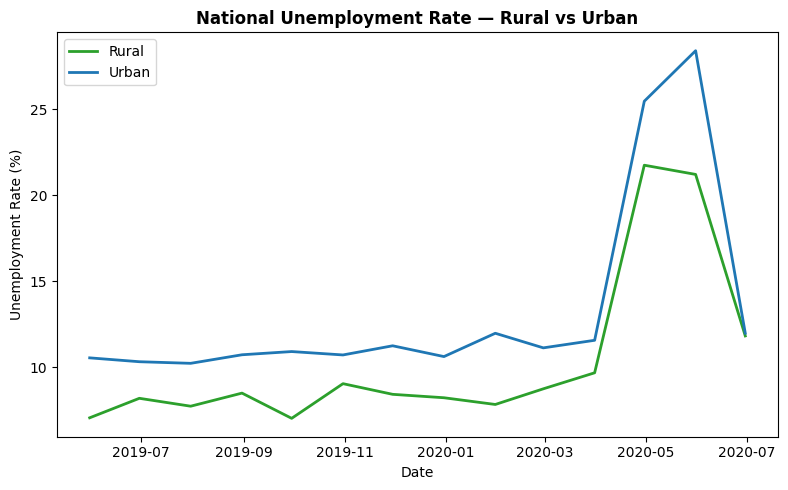

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for area, color in zip(['Rural', 'Urban'], ['#2ca02c', '#1f77b4']):
    # Average all states per date, for this area only
    subset = (df[df['Area'] == area]
              .groupby('Date')[UNEMP]
              .mean()
              .reset_index())

    ax.plot(subset['Date'], subset[UNEMP],
            color=color, linewidth=2, label=area)

ax.set_title('National Unemployment Rate — Rural vs Urban', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
fig.tight_layout()
fig.savefig('chart1_national_trend.png', dpi=150)
plt.show()


# Unemployment is higher in the urban area as compared to the rural area, but the trend is same across the years

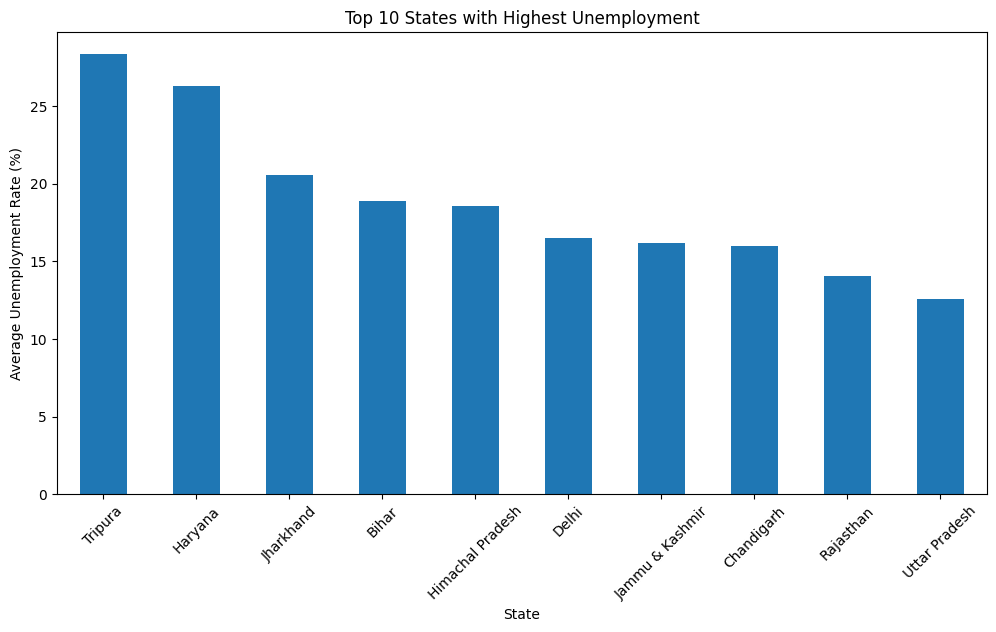

In [ ]:
# TOP 10 STATES

top_states = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
       .mean()
       .sort_values(ascending=False)
       .head(10)
)

plt.figure(figsize=(12,6))

top_states.plot(kind='bar')

plt.title("Top 10 States with Highest Unemployment")

plt.xlabel("State")

plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

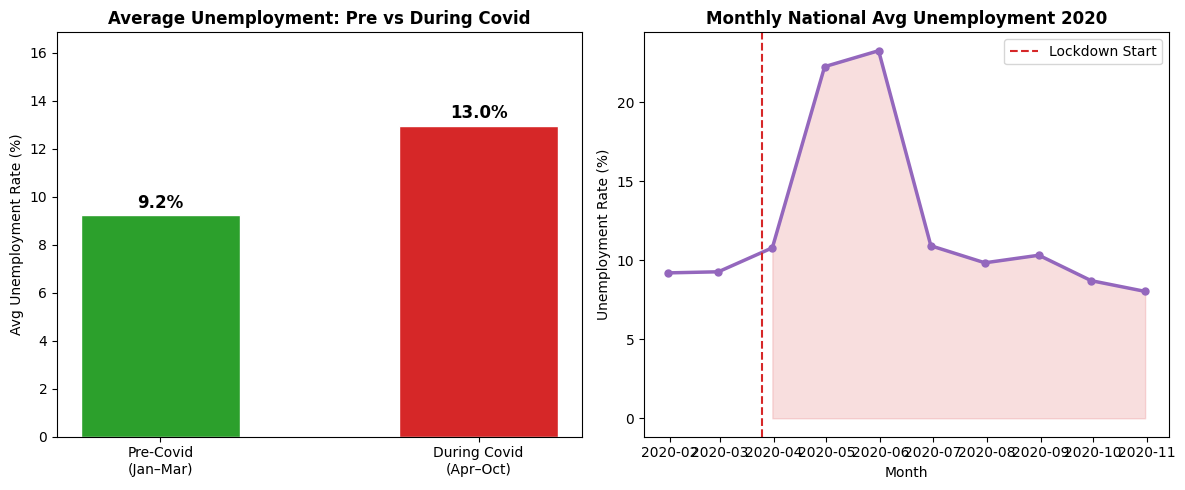

In [ ]:
# ── Figure with 2 side-by-side subplots ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: bar chart ──
bars = axes[0].bar(
    ['Pre-Covid\n(Jan–Mar)', 'During Covid\n(Apr–Oct)'],   # \n = line break inside the label
    [pre_avg, covid_avg],
    color=['#2ca02c', '#d62728'], width=0.5, edgecolor='white'
)

# Add value labels on top of each bar
for bar, val in zip(bars, [pre_avg, covid_avg]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

axes[0].set_title('Average Unemployment: Pre vs During Covid', fontweight='bold')
axes[0].set_ylabel('Avg Unemployment Rate (%)')
axes[0].set_ylim(0, max(pre_avg, covid_avg) * 1.3)

# ── Right: line chart with lockdown marker ──
monthly = df_1.groupby('Date')[UNEMP].mean().reset_index()

axes[1].plot(
    monthly['Date'], monthly[UNEMP],
    color='#9467bd', linewidth=2.5, marker='o', markersize=5
)

# Dashed red line = lockdown start
axes[1].axvline(LOCKDOWN, color='#d62728', linestyle='--', linewidth=1.5, label='Lockdown Start')

# Shade the Covid period in light red
axes[1].fill_between(
    monthly['Date'], monthly[UNEMP],
    where=[d >= LOCKDOWN for d in monthly['Date']],
    alpha=0.15, color='#d62728'
)

axes[1].set_title('Monthly National Avg Unemployment 2020', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].legend()

fig.tight_layout()
fig.savefig('chart2_covid_impact.png', dpi=150)
plt.show()

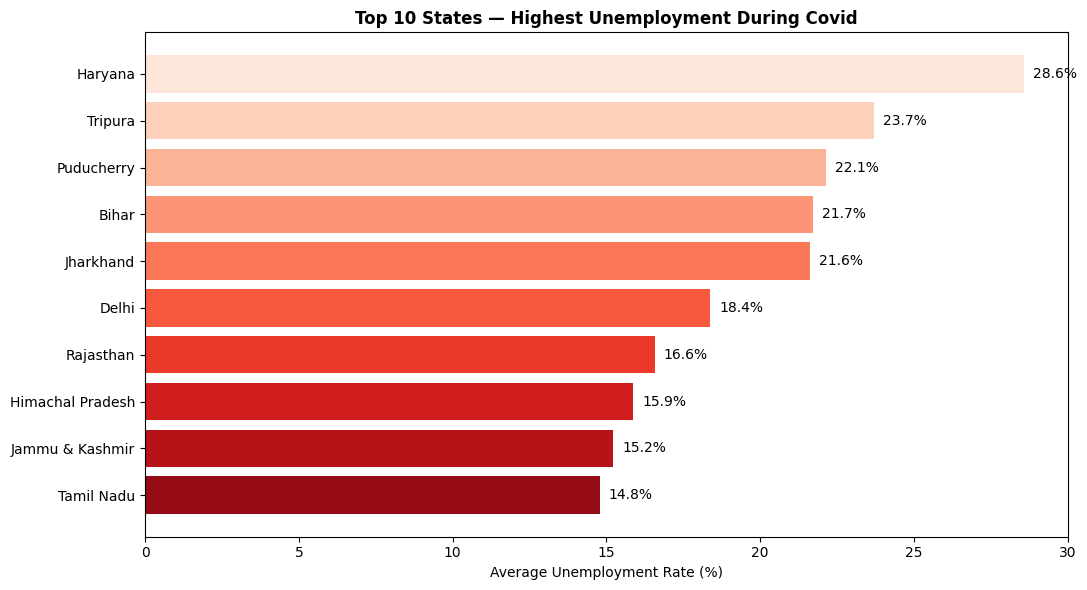

In [ ]:
# Filter to Covid period only, average by state
covid_df  = df_1[df_1['Period'] == 'During Covid']
state_avg = (covid_df.groupby('Region')[UNEMP]
             .mean()
             .sort_values(ascending=False)
             .head(10))

fig, ax = plt.subplots(figsize=(11, 6))

# [::-1] reverses so highest is at the top
bars = ax.barh(
    state_avg.index[::-1],
    state_avg.values[::-1],
    color=sns.color_palette('Reds_r', 10)
)

# Add value labels at the end of each bar
for bar, val in zip(bars, state_avg.values[::-1]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center')

ax.set_title('Top 10 States — Highest Unemployment During Covid', fontweight='bold')
ax.set_xlabel('Average Unemployment Rate (%)')
fig.tight_layout()
fig.savefig('chart3_top10_states.png', dpi=150)
plt.show()


# this are the top 10 most hit states with unemployment during the covid, with Haryana toping the chat at 28.6% and Tami Nadu being the least affected at 14.8%

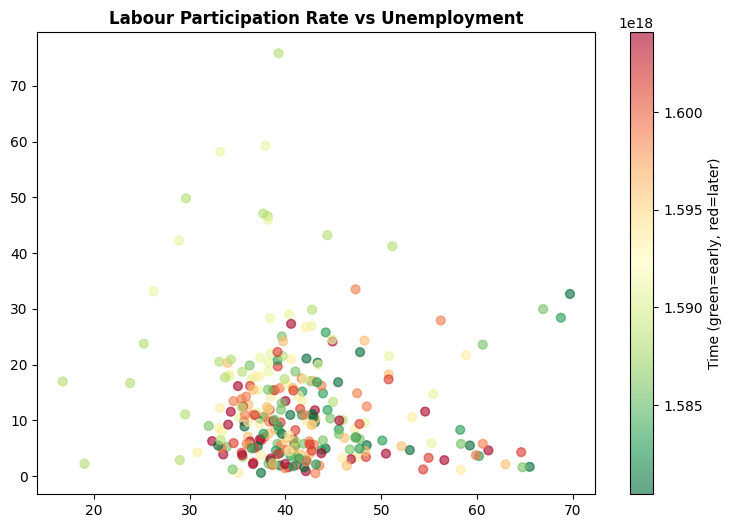

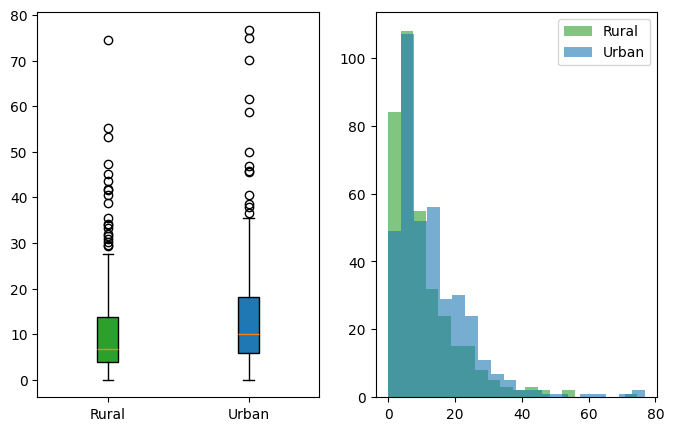

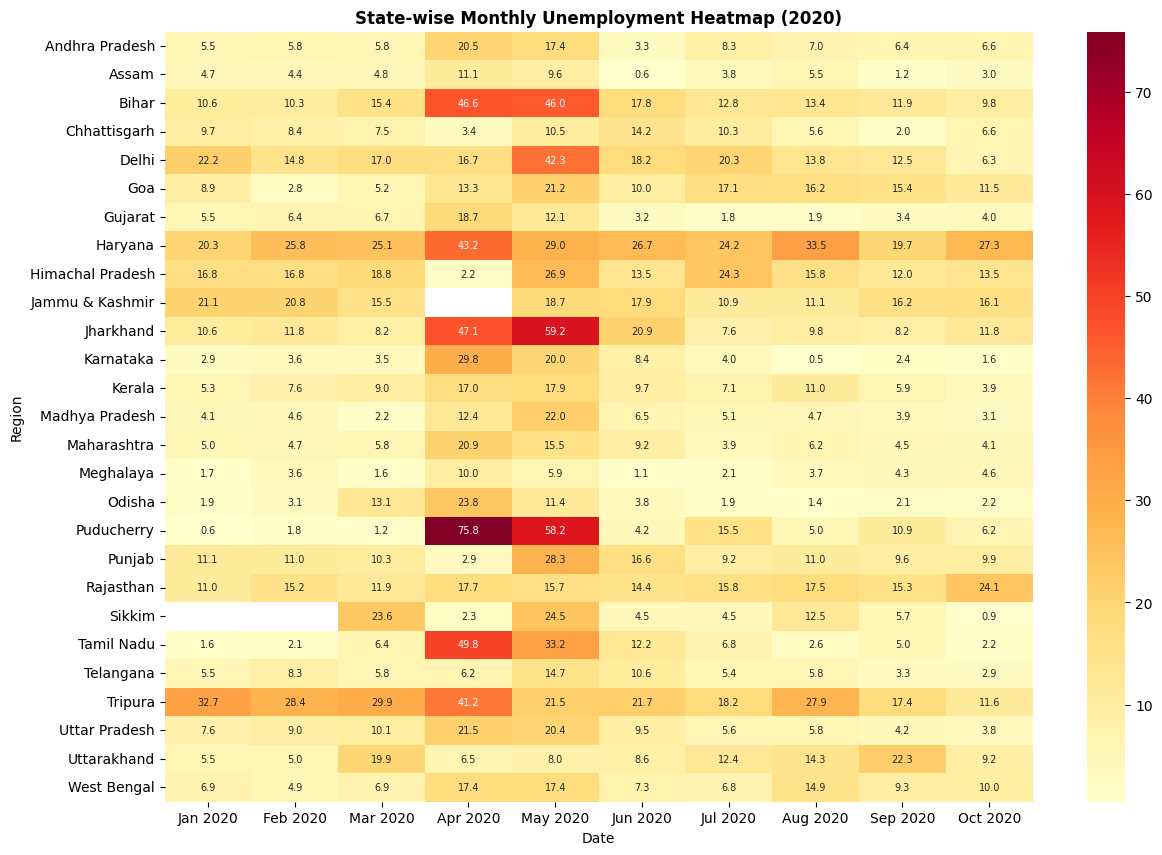

In [ ]:
#Labour Participation Rate vs Unemployment ──
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    df_1[LPR], df_1[UNEMP],
    c=df_1['Date'].astype('int64'),  # colour = time
    cmap='RdYlGn_r', alpha=0.6, s=40
)
fig.colorbar(scatter).set_label('Time (green=early, red=later)')
ax.set_title('Labour Participation Rate vs Unemployment', fontweight='bold')
fig.savefig('chart4_scatter.png', dpi=150); plt.show()

# Rural vs Urban box plot + histogram ──
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
data = [df[df['Area']=='Rural'][UNEMP].values,
        df[df['Area']=='Urban'][UNEMP].values]
bp = axes[0].boxplot(data, labels=['Rural', 'Urban'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ca02c')
bp['boxes'][1].set_facecolor('#1f77b4')
for area, color in zip(['Rural','Urban'],['#2ca02c','#1f77b4']):
    axes[1].hist(df[df['Area']==area][UNEMP], bins=20,
                 alpha=0.6, color=color, label=area)
axes[1].legend()
fig.savefig('chart5_rural_urban.png', dpi=150); plt.show()

# ── Chart 6: State × Month heatmap ──
pivot = df_1.pivot_table(
    index='Region', columns='Date', values=UNEMP, aggfunc='mean'
)
pivot.columns = pivot.columns.strftime('%b %Y')
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f',
            annot_kws={'size':7}, ax=ax)
ax.set_title('State-wise Monthly Unemployment Heatmap (2020)', fontweight='bold')
fig.savefig('chart6_heatmap.png', dpi=150); plt.show()
